What I want to do in the future is do this with normalization and without and see the difference centering at 0 does.  I'd also like to create a vslidation set and do more epochs with early stopping.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
x = np.random.randint(0, 5, size = (15,2))

In [3]:
x.shape

(15, 2)

In [4]:
def fx(x):
    assert x.shape[1]==2
    return (1*((x[:,0]-2.5)**2+(x[:,1]-2.5)**2-4>0)).reshape((x.shape[0],1))

In [5]:
y = fx(x)

In [6]:
means = x.mean(axis=0)

In [7]:
stds = x.std(axis=0)

In [8]:
x = (x-means)/stds

Creating a test set

In [9]:
x_test = np.random.randint(0, 5, size = (5,2))
y_test = fx(x_test)
x_test = (x_test-means)/stds

So I'm going to create a nueral network with two hidden layers and 1 output.  The first hiden layer will have 5 nodes, a relu activation, the second hidden layer with have 3 notes, with relu activation, and the output will be one unit with sigmoid activation

In [10]:
x

array([[ 1.15316401,  0.43346072],
       [-0.2306328 , -1.33978769],
       [-0.2306328 ,  0.43346072],
       [-1.61442961,  0.43346072],
       [ 1.15316401, -1.33978769],
       [ 0.4612656 ,  1.02454353],
       [ 1.15316401,  1.02454353],
       [-0.2306328 , -1.33978769],
       [-1.61442961,  1.02454353],
       [-0.92253121, -0.15762208],
       [ 0.4612656 , -1.33978769],
       [-1.61442961, -1.33978769],
       [ 0.4612656 ,  1.02454353],
       [ 0.4612656 ,  1.02454353],
       [ 1.15316401,  0.43346072]])

In [11]:
def relu(x):
    return x*1*(x>0)

In [12]:
def sigmoid(x):
    return 1/(1+np.exp(-1*x))

There are two inputs and five units in the first hidden layer so I need a weight matrix that's 2x5

In [13]:
w1 = np.random.randn(2,5)

In [14]:
b1 = np.random.randn(1,5)

There are 3 units in the next layer so weights need to be 5x3

In [15]:
w2 = np.random.randn(5,3)
b2 = np.random.randn(1,3)

In [16]:
w3 = np.random.randn(3,1)
b3 = np.random.randn(1,1)

In [17]:
def forward(x,w1,b1,w2,b2,w3,b3):
    z1 = np.matmul(x,w1)+b1
    h1 = relu(z1)
    z2 = np.matmul(h1,w2)+b2
    h2 = relu(z2)
    yhat = sigmoid(np.matmul(h2,w3)+b3)
    return yhat, h2, h1
    

In [18]:
learnrate = 0.03

In [19]:
def backward(x,y,yhat,h1,h2,w2,w3):
    n = y.shape[0]
    
    # output layer
    delta3 = yhat - y
    dw3 = h2.T@delta3/n
    db3 = np.sum(delta3,axis=0,keepdims=True)/n

    # layer2
    delta2 = (delta3@w3.T)*(h2>0)
    dw2 = h1.T@delta2/n
    db2 = np.sum(delta2,axis=0, keepdims=True)

    # layer 1
    delta1 = (delta2@w2.T)*(h1>0)
    dw1 = x.T@delta1/n
    db1 = np.sum(delta1, axis=0, keepdims=True)

    return dw1, db1, dw2, db2, dw3, db3

In [20]:
def loss(y, yhat):
    n = y.shape[0]
    return -1/n*(y*np.log(yhat)+(1-y)*np.log(1-yhat)).sum().item()

In [21]:
losses=[]
for epoch in range(20):
    yhat, h2, h1 = forward(x,w1,b1,w2,b2,w3,b3)
    train_loss = loss(y,yhat)
    losses.append(train_loss)
    dw1, db1, dw2, db2, dw3, db3 = backward(x,y,yhat,h1,h2,w2,w3)
    w1 -= learnrate*dw1
    b1 -= learnrate*db1
    w2 -= learnrate*dw2
    b2 -= learnrate*db2
    w3 -= learnrate*dw3
    b3 -= learnrate*db3
    if (epoch+1)%5==0:
        print(f"epoch: {epoch}, loss: {train_loss}")

epoch: 4, loss: 0.6904021145925567
epoch: 9, loss: 0.6475383023617857
epoch: 14, loss: 0.6249050448995408
epoch: 19, loss: 0.6073838896880596


In [22]:
yhat_test, *_ = forward(x_test, w1,b1,w2,b2,w3,b3)
loss(y_test, yhat_test)

0.6640376041009851

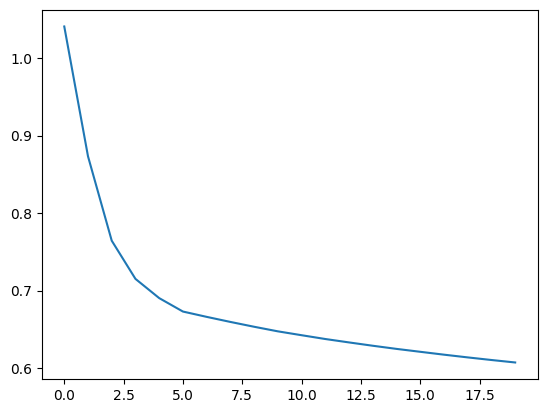

In [23]:
plt.plot(list(range(20)),losses)